In [ ]:
from google.colab import drive, files
uploaded = files.upload()
drive.mount('/content/drive')

In [ ]:
import pandas as pd

# the processed data already has lyrics split into verbs, nouns, adverbs, corpus, words counts, unique word counts etc
processedData = pd.read_csv("all_songs_data_processed.csv")

regData = pd.read_csv("all_songs_data.csv")
regData.head()

#clean dataset
#drop uneeded columns
regData = regData.drop(columns=['Media'])
regData = regData.drop(columns=['Song URL'])
regData = regData.drop(columns=['Album URL'])
regData = regData.drop(columns=['Writers'])
regData = regData.drop(columns=['Featured Artists'])
regData.head()

print(regData.dtypes)
#change Year and Release Date columns to correct types
#changing year to int
regData["Year"] = regData["Year"].astype("int64")
#change release date to date
regData["Release Date"] = pd.to_datetime(regData["Release Date"], errors='coerce')
regData["Release Date"] = regData["Release Date"].dt.normalize()

#see how many nulls are in each column
regData.isnull().sum()
#album- 464
#lyrics- 116
#release date- 1937
#6500 total rows

nolyric = regData[regData["Lyrics"].isnull()]
nolyric['Rank'].value_counts(sort=False)

#all of the rows that have no lyrics also have no album or release date, going to drop those becuase we need the lyrics to do this project
regData[regData["Lyrics"].isnull()]
regData[regData["Lyrics"].isna()]["Rank"].value_counts().sort_index()
regData[regData["Lyrics"].isna()]["Year"].value_counts().sort_index()
#lyric nulls seem to be fairly random so not to worried about there being any sort of correlation, and we need the lyrics to do the assingment so have to drop these ones
#drop null lyrics
regData = regData.dropna(subset=['Lyrics'])

regData.isnull().sum()
#now have 348 null albums,1821 null release dates
#look at album nulls
regData[regData["Album"].isnull()]
regData[regData["Album"].isna()]["Rank"].value_counts().sort_index()
regData[regData["Album"].isna()]["Year"].value_counts().sort_index()
#1960s have the most null albums, but going to leave these because Album doesn't really affect the analysis that much, I think its okay for there to be some nulls
#look at release date nulls
regData[regData["Release Date"].isnull()]
regData[regData["Release Date"].isna()]["Year"].value_counts().sort_index()
#theres a lot of null release dates, want to see if any are ranked in multiple years
nullDates = regData[regData['Release Date'].isna()]
nullDates['Song Title'].value_counts().head(60)
nullCounts = nullDates['Song Title'].value_counts()
nullCounts1 = nullCounts[nullCounts > 1]
nullDateRepeats = regData['Song Title'].isin(nullCounts1)
regData[nullDateRepeats]

#noticed one song had incorrect lyrics, going to fix that
regData['Song Title'].value_counts()
regData[regData["Song Title"] == "Stay"]
correctlyrics = regData.loc[
    (regData["Year"] == 2022) &
    (regData["Artist"] == "The Kid Laroi and Justin Bieber") &
    (regData["Album"] == "Fuser Soundtrack"),
    "Lyrics"
].iloc[0]
regData.loc[
    (regData["Year"] == 2021) &
    (regData["Artist"] == "The Kid Laroi and Justin Bieber") &
    (regData["Album"] == "NOW That’s What I Call Music! 96 [UK]"),
    "Lyrics"
] = correctlyrics







Album            object
Artist           object
Lyrics           object
Rank              int64
Release Date     object
Song Title       object
Year            float64
dtype: object


In [ ]:
# splitting up the words
import spacy
nlp = spacy.load("en_core_web_sm")

#going to add a new column for the cleaned lyrics
regData['cleanedLyrics'] = (
    regData['Lyrics']
    .str.lower()    #puts them all in lowercase
    .str.replace(r"\[.*?\]", "", regex=True)     #removes everythign inside bracketes [ ]
    .str.replace(r"(chorus|verse|bridge|intro|outro|featuring)\s*\d*:", "", regex=True)     #remove any other 'chores', 'verse', etc. from the lyrics
    .str.replace(r"[^a-z\s]", "", regex=True)      #strips so only letters a-z and spaces are included
    .str.replace(r"\s+", " ", regex=True)          #remove extra spaces
    .str.strip()                                   #remove leading/trailing spaces
)

#make each word a token
regData['tokens'] = regData['cleanedLyrics'].apply(
    lambda text: [t.lemma_ for t in nlp(text) if t.is_alpha and not t.is_stop and len(t.lemma_) > 1]
    #the t.lemms_ converts words into their base form
    #the not t.is_stop removes 'stop words like and, is, you etc.
)



In [ ]:
#putting all the lyrics into english
!pip install langdetect
from langdetect import detect

def safe_detect(text):
    try:
        return detect(text)
    except:
        return None

regData["language"] = regData["Lyrics"].apply(
    lambda x: safe_detect(x) if pd.notna(x) else None
)
regData["language"].value_counts()

#looking at all the different languages
regData[regData["language"] == "ro"]
#these are all instramentals- no lyrics so going to keep them
regData[regData["language"] == "ro"]["Rank"].value_counts().sort_index()
regData[regData["language"] == "ro"]["Year"].value_counts().sort_index()
#pretty randomly distributed, might have to remove all songs from before 1970s because they seem to have the most issues

#looking at spanish
regData[regData["language"] == "es"]
#a lot of these are not incorrect entries, just songs by spanish artists
# so going to keep them separate for now instead of translating them in place
spanishRows = regData[regData["language"] == "es"].copy()

#running into error with songs that have books instead of lyrics,
#maybe focus on correcting those, then come back to languages
#for the main analysis, keep only English songs for now
regData = regData[regData["language"] == "en"].copy()
regData.reset_index(drop=True, inplace=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=10750f11ae36ea7661ca50669a7134b1ee34bd127ec87849014592633c82731e
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


num songs in each bin [ 65 252 463 638 639 663 588 474 423 326 261 209 147 159 137 116  98 103
  76  59  57  25  36  30  15  11  16  16   3   3  12   3   1   2   6   1
   3   0   2   1   0   0   1   1   0   2   0   0   0   0   1   1   1   0
   0   0   1   0   1   1   0   0   2   1   0   0   0   0   0   0   0   0
   1   3   1   0   1   0   0   1]
bin edges [  22.      38.575   55.15    71.725   88.3    104.875  121.45   138.025
  154.6    171.175  187.75   204.325  220.9    237.475  254.05   270.625
  287.2    303.775  320.35   336.925  353.5    370.075  386.65   403.225
  419.8    436.375  452.95   469.525  486.1    502.675  519.25   535.825
  552.4    568.975  585.55   602.125  618.7    635.275  651.85   668.425
  685.     701.575  718.15   734.725  751.3    767.875  784.45   801.025
  817.6    834.175  850.75   867.325  883.9    900.475  917.05   933.625
  950.2    966.775  983.35   999.925 1016.5   1033.075 1049.65  1066.225
 1082.8   1099.375 1115.95  1132.525 1149.1   1165.675 118

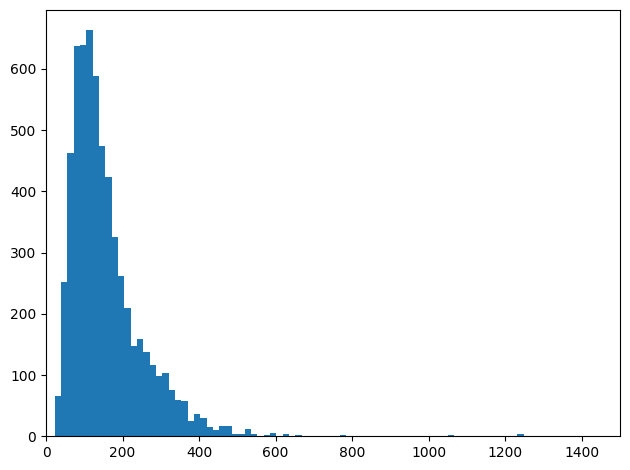

Upper cutoff: 476.84000000000015


,Album,Artist,Lyrics,Rank,Release Date,Song Title,Year,cleanedLyrics,tokens,language,tokenCount
0,Battle of New Orleans,Johnny Horton,[Verse 1] In 1814 we took a little trip Along ...,1,1959-04-01,The Battle Of New Orleans,1959,in we took a little trip along with colonel ja...,"[take, little, trip, colonel, jackson, mighty,...",en,199
1,That’s All,Bobby Darin,"Oh the shark, babe Has such teeth, dear And he...",2,NaT,Mack The Knife,1959,oh the shark babe has such teeth dear and he s...,"[oh, shark, babe, tooth, dear, show, pearly, w...",en,122
2,“Mr Personality’s” 15 Big Hits,Lloyd Price,Over and over I tried to prove my love to you ...,3,NaT,Personality,1959,over and over i tried to prove my love to you ...,"[try, prove, love, friend, say, fool, ill, foo...",en,81
3,The Greatest Hits Of Frankie Avalon,Frankie Avalon,"Hey, Venus! Oh, Venus! Venus, if you will Ple...",4,NaT,Venus,1959,hey venus oh venus venus if you will please se...,"[hey, venus, oh, venus, venus, send, little, g...",en,67
4,Paul Anka Sings His Big 15,Paul Anka,I'm just a lonely boy Lonely and blue I'm all ...,5,NaT,Lonely Boy,1959,im just a lonely boy lonely and blue im all al...,"[lonely, boy, lonely, blue, nothin, ve, get, t...",en,53


In [ ]:
import matplotlib.pyplot as plt

#looking at the amount of tokens in each song
regData["tokenCount"] = regData["tokens"].apply(len)
regData["tokenCount"].describe()
regData.nlargest(100, "tokenCount")[["Song Title", "Year", "Artist", "tokenCount", "Lyrics"]]

#making a histogram of lyrics distrabution to better understand what we're dealing with
counts, bins, _ = plt.hist(regData["tokenCount"], bins=80)
counts = counts.astype(int)
print("num songs in each bin", counts)  # number of songs in each bin
print("bin edges", bins)    # bin edges
plt.xlim(0, 1500) #Make the graph look better compared to keeping no limits; should still fit within regData
plt.tight_layout() # Tighten the graph for a cleaner visual
plt.show()

#some songs are extremely long, which may mean they are book-like entries or bad scrape data
#going to remove the top 1% as outliers so they do not distort the analysis
upper_cutoff = regData["tokenCount"].quantile(0.99)
print("Upper cutoff:", upper_cutoff)

#first make a new table to hold only those long songs
longsongs = regData[regData["tokenCount"] > upper_cutoff].copy()

#keep the cleaned dataset without those extreme outliers
regData = regData[regData["tokenCount"] <= upper_cutoff].copy()

#also remove very short entries that do not give enough text for analysis
regData = regData[regData["tokenCount"] >= 20].copy()

regData.reset_index(drop=True, inplace=True)
regData.head()



In [ ]:
#adding a few simple text features for the rest of the analysis
#these will help us compare songs by rank, year, and word usage

regData["uniqueWordCount"] = regData["tokens"].apply(lambda x: len(set(x)))
regData["avgWordLength"] = regData["tokens"].apply(
    lambda toks: sum(len(w) for w in toks) / len(toks) if len(toks) > 0 else 0
)
regData["lexicalRichness"] = regData.apply(
    lambda row: row["uniqueWordCount"] / row["tokenCount"] if row["tokenCount"] > 0 else 0,
    axis=1
)

regData[["Song Title", "Year", "Rank", "tokenCount", "uniqueWordCount", "avgWordLength", "lexicalRichness"]].head()

,Song Title,Year,Rank,tokenCount,uniqueWordCount,avgWordLength,lexicalRichness
0,The Battle Of New Orleans,1959,1,199,90,5.497487,0.452261
1,Mack The Knife,1959,2,122,82,4.516393,0.672131
2,Personality,1959,3,81,23,5.493827,0.283951
3,Venus,1959,4,67,36,4.462687,0.537313
4,Lonely Boy,1959,5,53,26,4.452830,0.490566


In [ ]:
#saving the cleaned dataset so everyone in the group can use the same version
#this should be the main file used for the rest of the project

regData.to_csv(
    "all_songs_data_cleaned.csv",
    index=False
)

print("cleaned dataset saved")

cleaned dataset saved


[('not', 34720), ('love', 21623), ('know', 16930), ('like', 14730), ('get', 14467), ('oh', 13402), ('baby', 13347), ('yeah', 13267), ('go', 9569), ('come', 8977), ('let', 8840), ('want', 8700), ('to', 7719), ('time', 7515), ('girl', 7412), ('cause', 6855), ('wanna', 6447), ('feel', 6249), ('tell', 6161), ('way', 6119), ('ve', 5985), ('ill', 5542), ('need', 5473), ('night', 5266), ('right', 5211)]


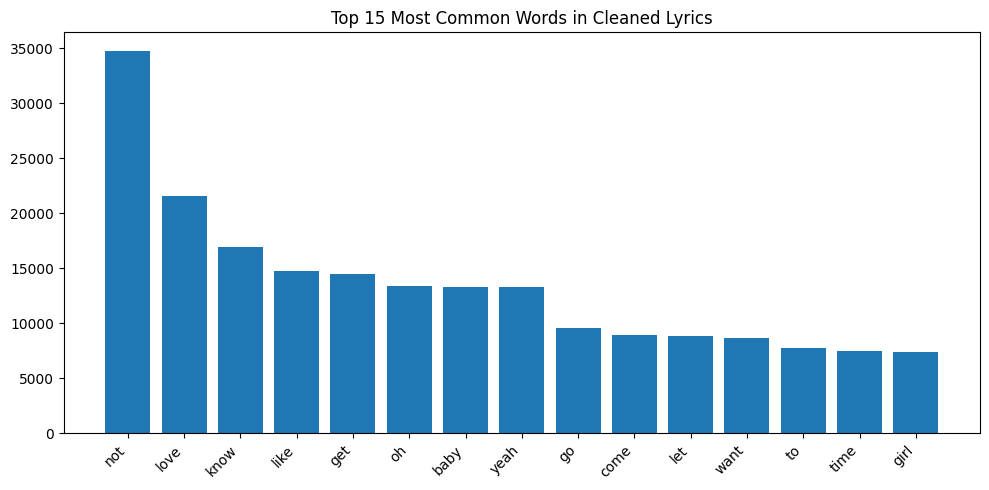

In [ ]:
#looking at the most common words in the cleaned lyrics
#this helps us see whether high-ranking songs tend to use different language

from collections import Counter

allTokens = [token for tokens in regData["tokens"] for token in tokens]
wordCounts = Counter(allTokens)

print(wordCounts.most_common(25))

#plotting the top 15 most common words
topWords = wordCounts.most_common(15)
words = [w for w, c in topWords]
counts = [c for w, c in topWords]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 Most Common Words in Cleaned Lyrics")
plt.tight_layout()
plt.show()

Ways to analyze:
*   TF-IDF : identifies important words vs commonly used words, can find words that make a song unique
*   Sentiment analysis : determine 'happy' vs 'sad' songs
*   N-grams : analyzes sequences of words instead of the individual words
*   Topic modeling : automatically finds themes in the data
    * common method- LDA (Latent Dirichlet Allocation)
* word embeddings/semantic analysis - Word2vec or GloVe- analyze relationships between words based on conext- can find words used similarly across songs, anaylze lyrical style and semantics
* Clustering : can group songs into groups- love songs, party songs etc.
* Classification : can predict song's genre, artist, rank?
  * clustering and classification use machine learning after lyrics are converted to numerical features(TF-IDF)



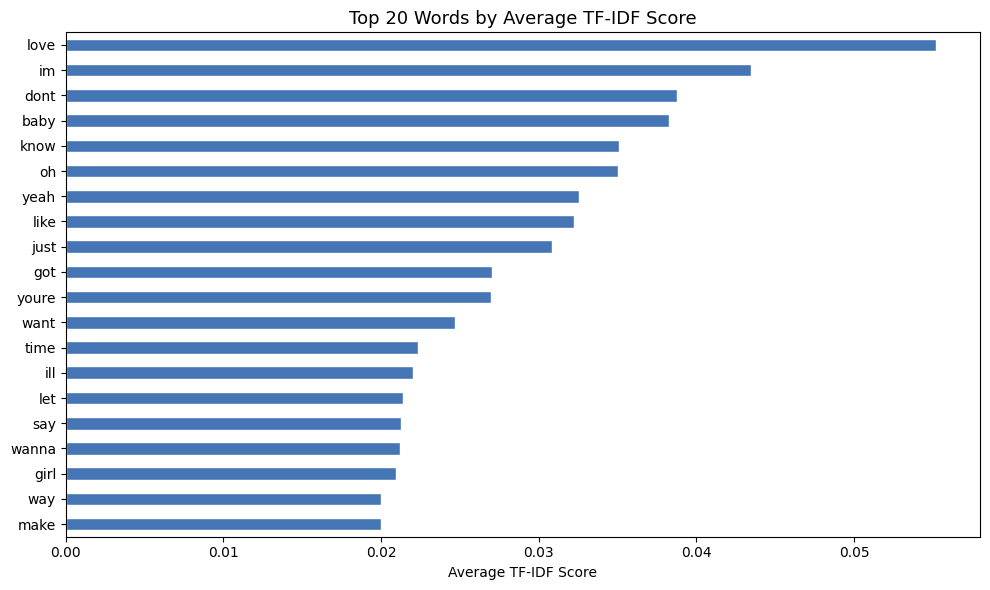

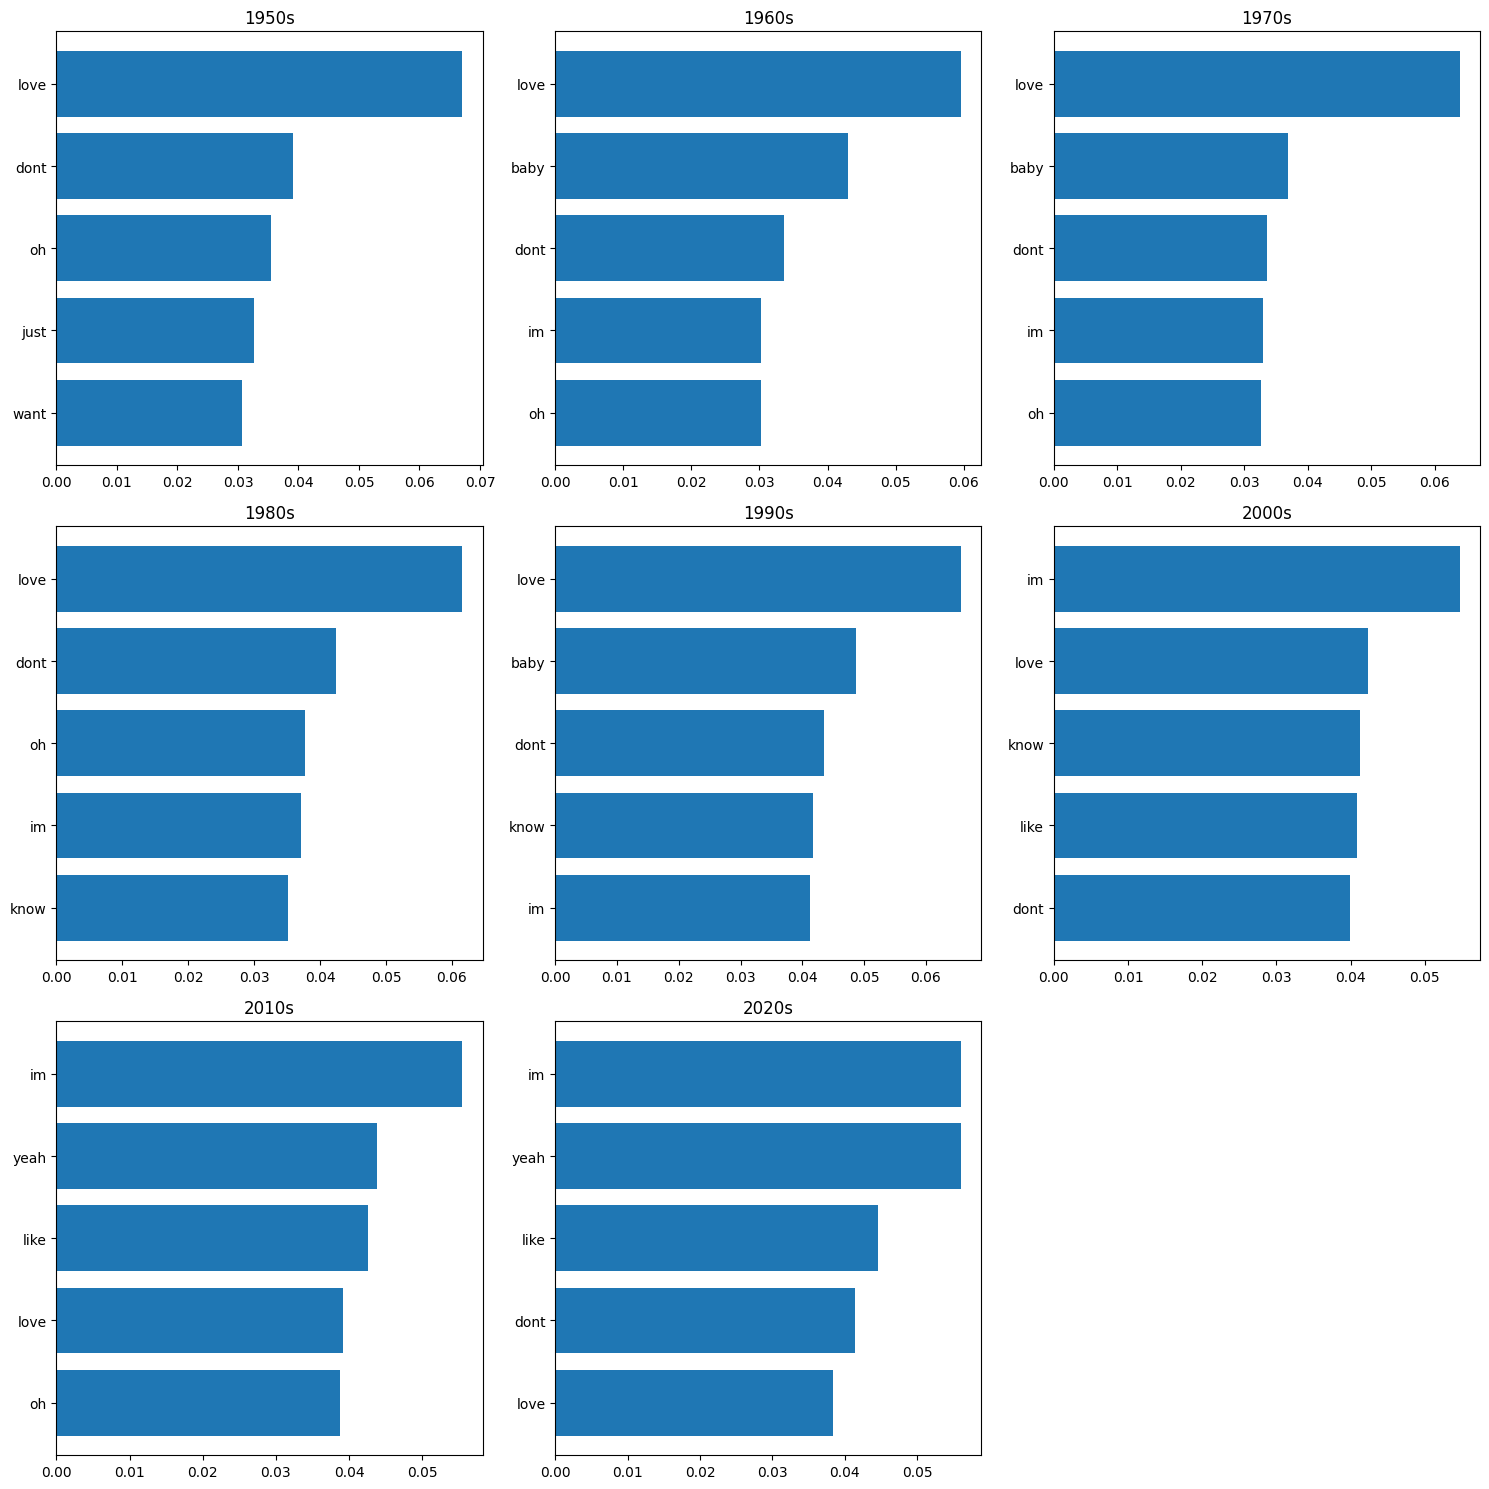

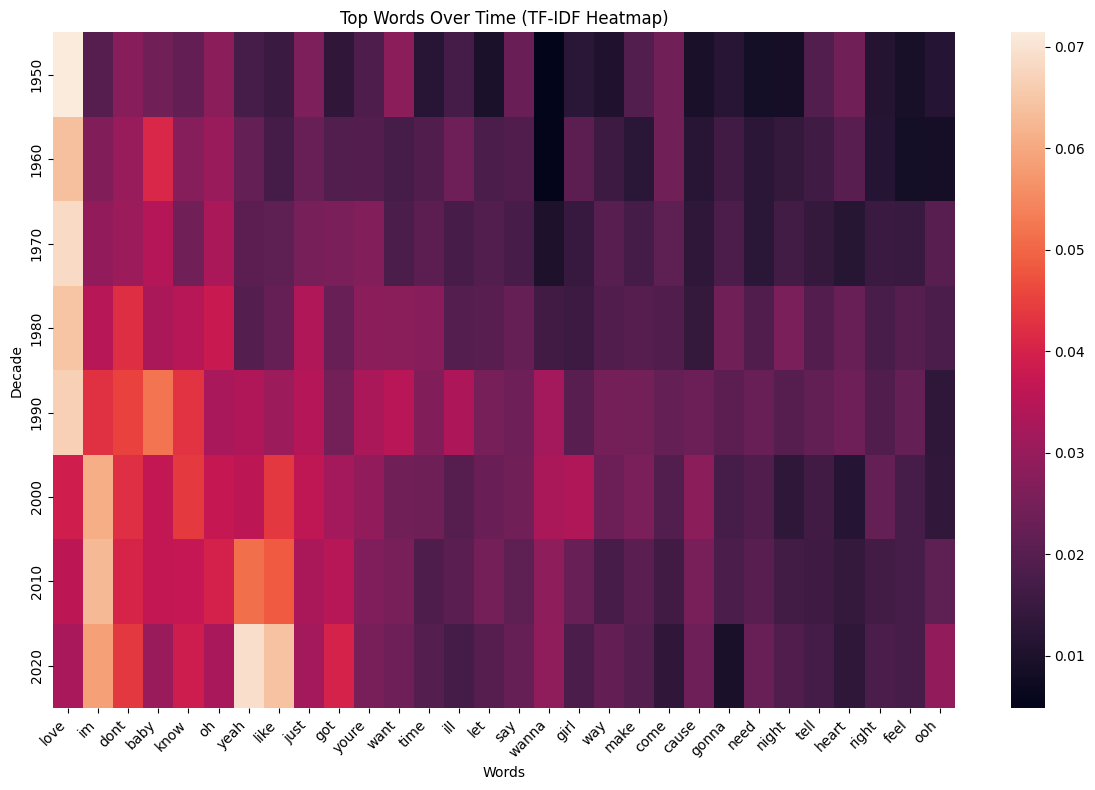

In [ ]:
#TF-IDF analysis
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import seaborn as sns
import math

tfidf_vec = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf_vec.fit_transform(regData['cleanedLyrics'])

#top 20 words by average TF-IDF score across all reviews
avg_tfidf = pd.Series(tfidf_matrix.mean(axis=0).A1, index=tfidf_vec.get_feature_names_out())
top_words = avg_tfidf.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_words.sort_values().plot(kind='barh', color='#4575b4', edgecolor='white')
plt.title('Top 20 Words by Average TF-IDF Score', fontsize=13)
plt.xlabel('Average TF-IDF Score')
plt.tight_layout()
plt.show()

#these are the words that are most 'informative' across the songs

#going to look at the TD-IDF for each year

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vec.get_feature_names_out()
)

tfidf_df['Year'] = regData['Year'].values

top_words_by_year = {}

for year, group in tfidf_df.groupby('Year'):
    avg_tfidf = group.drop(columns='Year').mean()
    top_words = avg_tfidf.sort_values(ascending=False).head(20)
    top_words_by_year[year] = top_words


#analyze by decade
regData['Decade'] = (regData['Year'] // 10) * 10


decades = sorted(regData['Decade'].unique())
n = len(decades)

cols = 3  # number of plots per row
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, decade in enumerate(decades):
    group = regData[regData['Decade'] == decade]

    tfidf_vec = TfidfVectorizer(stop_words='english', max_features=5000)
    tfidf_matrix = tfidf_vec.fit_transform(group['cleanedLyrics'])

    avg_tfidf = pd.Series(
        tfidf_matrix.mean(axis=0).A1,
        index=tfidf_vec.get_feature_names_out()
    )

    top_words = avg_tfidf.sort_values(ascending=False).head()

    axes[i].barh(top_words.sort_values().index, top_words.sort_values().values)
    axes[i].set_title(f'{decade}s')

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()








#so we can plot heatmap by decades
tfidf_df['Decade'] = (regData['Year'] // 10) * 10

#find overall top words
top_words_overall = (
    tfidf_df.drop(columns=['Decade', 'Year'])
    .mean()
    .sort_values(ascending=False)
    .head(30)
    .index
)

#group by decade
heatmap_data = (
    tfidf_df.groupby('Decade')[top_words_overall]
    .mean()
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data)

plt.title('Top Words Over Time (TF-IDF Heatmap)')
plt.xlabel('Words')
plt.ylabel('Decade')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
#the lighter the color, the strong that word is as a characteristic of that decade

In [ ]:
regData

,Album,Artist,Lyrics,Rank,Release Date,Song Title,Year,cleanedLyrics,tokens,language,tokenCount,uniqueWordCount,avgWordLength,lexicalRichness,Decade
0,Battle of New Orleans,Johnny Horton,[Verse 1] In 1814 we took a little trip Along ...,1,1959-04-01,The Battle Of New Orleans,1959,in we took a little trip along with colonel ja...,"[take, little, trip, colonel, jackson, mighty,...",en,199,90,5.497487,0.452261,1950
1,That’s All,Bobby Darin,"Oh the shark, babe Has such teeth, dear And he...",2,NaT,Mack The Knife,1959,oh the shark babe has such teeth dear and he s...,"[oh, shark, babe, tooth, dear, show, pearly, w...",en,122,82,4.516393,0.672131,1950
2,“Mr Personality’s” 15 Big Hits,Lloyd Price,Over and over I tried to prove my love to you ...,3,NaT,Personality,1959,over and over i tried to prove my love to you ...,"[try, prove, love, friend, say, fool, ill, foo...",en,81,23,5.493827,0.283951,1950
3,The Greatest Hits Of Frankie Avalon,Frankie Avalon,"Hey, Venus! Oh, Venus! Venus, if you will Ple...",4,NaT,Venus,1959,hey venus oh venus venus if you will please se...,"[hey, venus, oh, venus, venus, send, little, g...",en,67,36,4.462687,0.537313,1950
4,Paul Anka Sings His Big 15,Paul Anka,I'm just a lonely boy Lonely and blue I'm all ...,5,NaT,Lonely Boy,1959,im just a lonely boy lonely and blue im all al...,"[lonely, boy, lonely, blue, nothin, ve, get, t...",en,53,26,4.452830,0.490566,1950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6092,Gumbo,Young Nudy featuring 21 Savage,This how it sound when I hit your ho Be like t...,94,2023-02-28,Peaches & Eggplants,2023,this how it sound when i hit your ho be like t...,"[sound, hit, ho, like, like, like, ho, like, l...",en,363,125,4.066116,0.344353,2020
6093,One Thing At A Time,Morgan Wallen,When it comes to hitchin' the boat up Backin' ...,95,2023-01-31,I Wrote the Book,2023,when it comes to hitchin the boat up backin do...,"[come, hitchin, boat, backin, ramp, old, truck...",en,175,78,4.554286,0.445714,2020
6094,L3*,Latto featuring Cardi B,(Go Grizz) Ah (Squat made the beat) What's hap...,98,2023-06-02,Put It on da Floor Again,2023,go grizz ah squat made the beat whats happenin...,"[grizz, ah, squat, beat, happenin, bardi, big,...",en,306,167,4.209150,0.545752,2020
6095,Born This Way,Lady Gaga,Money [Verse 1] Love is just a history that t...,99,2011-05-23,Bloody Mary,2023,money love is just a history that they may pro...,"[money, love, history, prove, go, ill, tell, r...",en,179,58,4.307263,0.324022,2020


##New dataset

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')
uploaded = files.upload()


MessageError: Error: credential propagation was unsuccessful

In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
print("Number of songs:", len(regData))
print("Number of columns:", regData.shape[1])
print("Year range:", regData["Year"].min(), "to", regData["Year"].max())
print("Number of unique artists:", regData["Artist"].nunique())
print("Number of unique song titles:", regData["Song Title"].nunique())

Number of songs: 6097
Number of columns: 15
Year range: 1959 to 2023
Number of unique artists: 2920
Number of unique song titles: 5442


In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
print(regData.isnull().sum().sort_values(ascending=False))

Release Date       1706
Album               282
Artist                0
Lyrics                0
Rank                  0
Song Title            0
Year                  0
cleanedLyrics         0
tokens                0
language              0
tokenCount            0
uniqueWordCount       0
avgWordLength         0
lexicalRichness       0
Decade                0
dtype: int64


In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
print(regData["language"].value_counts().head(10))

language
en    6097
Name: count, dtype: int64


In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
print(regData["tokenCount"].describe())

count    6097.000000
mean      152.236346
std        84.176576
min        22.000000
25%        91.000000
50%       131.000000
75%       190.000000
max       476.000000
Name: tokenCount, dtype: float64


In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
regData["tokenCount"] = regData["tokens"].apply(len)
print(regData["tokenCount"].describe())

count    6097.000000
mean      152.236346
std        84.176576
min        22.000000
25%        91.000000
50%       131.000000
75%       190.000000
max       476.000000
Name: tokenCount, dtype: float64


In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
print(regData["Artist"].value_counts().head(10))

Artist
Madonna            35
Mariah Carey       28
Taylor Swift       28
Elton John         24
Beatles            24
Michael Jackson    22
Rihanna            21
Stevie Wonder      21
Janet Jackson      20
Whitney Houston    20
Name: count, dtype: int64


In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
songs_per_year = regData["Year"].value_counts().sort_index()
print(songs_per_year.head())
print(songs_per_year.tail())

Year
1959    82
1960    88
1961    86
1962    90
1963    91
Name: count, dtype: int64
Year
2019    92
2020    88
2021    86
2022    83
2023    86
Name: count, dtype: int64


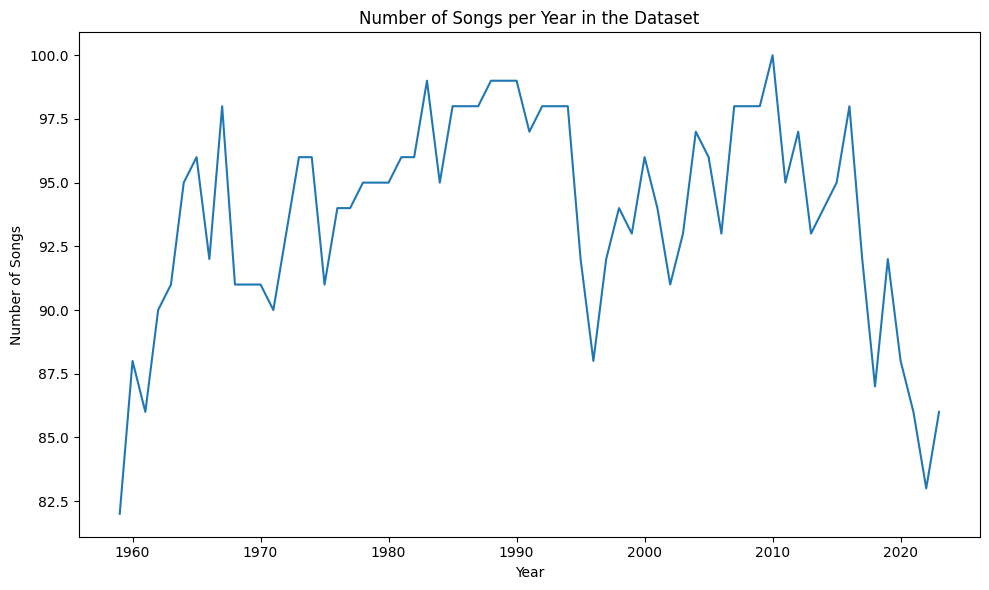

In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
import matplotlib.pyplot as plt

songs_per_year = regData["Year"].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(songs_per_year.index, songs_per_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.title("Number of Songs per Year in the Dataset")
plt.tight_layout()
plt.show()

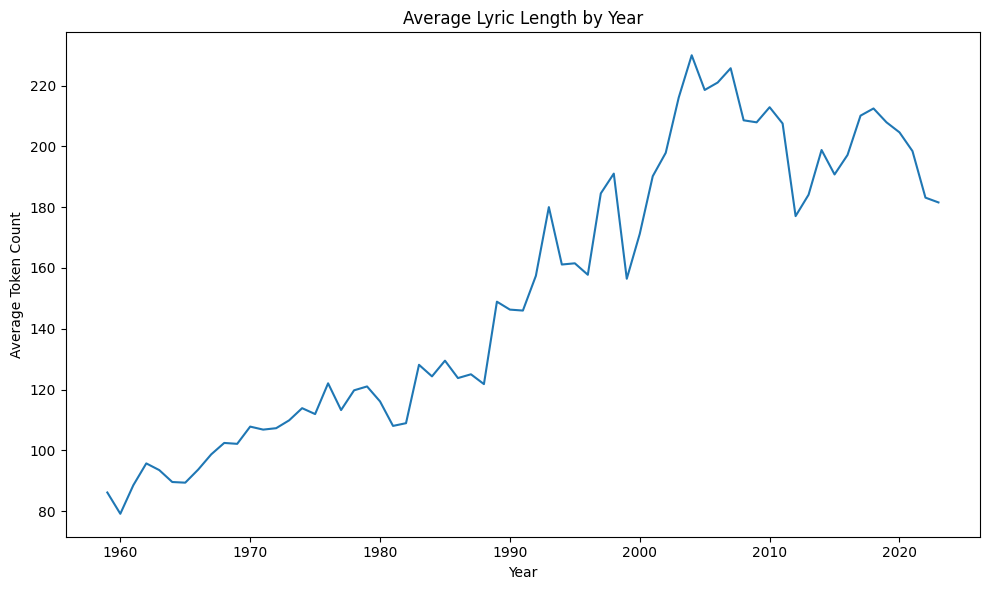

In [ ]:
#BASIC BACKGROUND INFORMATION, FEEL FREE TO DELETE FOR FINAL SUBMISSION
avg_tokens_by_year = regData.groupby("Year")["tokenCount"].mean()

plt.figure(figsize=(10,6))
plt.plot(avg_tokens_by_year.index, avg_tokens_by_year.values)
plt.xlabel("Year")
plt.ylabel("Average Lyric Count")
plt.title("Average Lyric Length by Year")
plt.tight_layout()
plt.show()